Load pre-split data from data_preparation.ipynb

In [1]:
import pandas as pd
import numpy as np

train_a = pd.read_csv("../../data/train_a.csv")
test_a  = pd.read_csv("../../data/test_a.csv")
train_b = pd.read_csv("../../data/train_b.csv")
test_b  = pd.read_csv("../../data/test_b.csv")

feature_cols = [c for c in train_a.columns if c not in ("name", "status")]

print(f"Train A: {len(train_a)} rows | Test A: {len(test_a)} rows")
print(f"Train B: {len(train_b)} rows | Test B: {len(test_b)} rows")

Train A: 152 rows | Test A: 43 rows
Train B: 146 rows | Test B: 41 rows


Logistig regression Train

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso,  LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error,
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.feature_selection import SelectFromModel
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

Results from Dataset A: (with LASSO und Ridge)

[-0.01812233 -0.         -0.01689895  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.         -0.         -0.          0.          0.
  0.11325604  0.          0.          0.        ]
Best alpha: 0.1
[-0.05827315 -0.00138901 -0.05385075 -0.01484781 -0.00423164  0.00097378
 -0.010758   -0.0006544   0.00801388  0.00470258  0.00406893  0.00599696
  0.01560318  0.00406173 -0.02442164 -0.00590547  0.00266855  0.00926773
  0.06241811  0.01235879  0.04617155  0.04818971]
Best alpha: 100.0

Lasso scores (Dataset A):
  Train: R²=0.256  MSE=0.134  MAE=0.303  RMSE=0.367
  Test: R²=0.291  MSE=0.143  MAE=0.276  RMSE=0.378

Ridge scores (Dataset A):
  Train: R²=0.356  MSE=0.116  MAE=0.274  RMSE=0.341
  Test: R²=0.425  MSE=0.116  MAE=0.221  RMSE=0.340

Selected features (3/22): ['MDVP:Fo(Hz)', 'MDVP:Flo(Hz)', 'spread1']


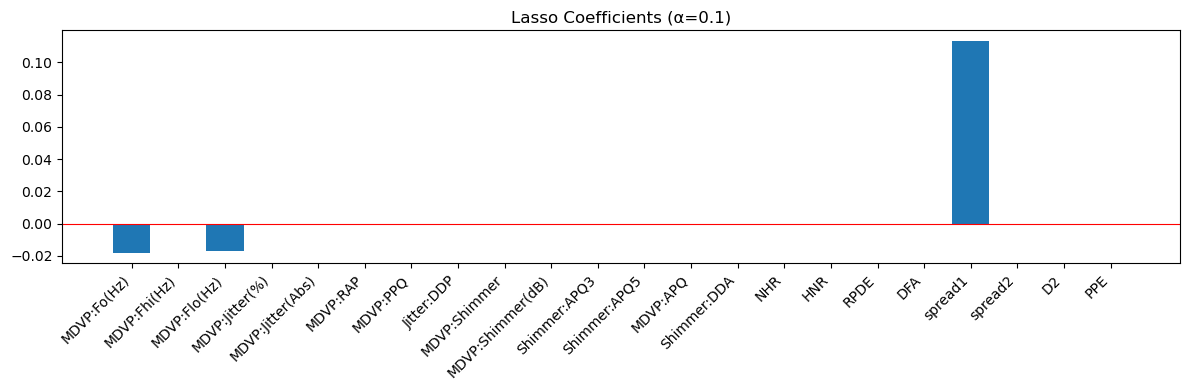

In [3]:
#---Step 0: Load dataset A

feature_cols = [c for c in train_a.columns if c not in ("name", "subject_id", "status")]
X_train = train_a[feature_cols]
y_train = train_a["status"]

X_test = test_a[feature_cols]
y_test = test_a["status"]

# Step 1: data normalization

#X_train = np.log1p(X_train)
#X_test  = np.log1p(X_test)

scaler  = StandardScaler().fit(X_train) # fit() learns mean and std parameters
X_train = scaler.transform(X_train) # transform() normalizes
X_test  = scaler.transform(X_test)
    
# Step 2: Hyperparameter Tuning with Lasso (L1 regularization) and GridSearchCV (5-fold Cross validation)
param_grid = {'alpha': np.logspace(-6, 6, 13)}

lasso_grid = GridSearchCV(
    Lasso(fit_intercept=True, max_iter=10000),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)
lasso_grid.fit(X_train, y_train)

best_lasso   = lasso_grid.best_estimator_
w_star_Lasso = best_lasso.coef_
print(w_star_Lasso)
print(f"Best alpha: {lasso_grid.best_params_['alpha']}")

# Tuning with Ridge regression (L2 regularization) for comparison
ridge_grid = GridSearchCV(
    Ridge(fit_intercept=True, max_iter=10000),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)
ridge_grid.fit(X_train, y_train)

best_ridge   = ridge_grid.best_estimator_
w_star_Ridge = best_ridge.coef_
print(w_star_Ridge)
print(f"Best alpha: {ridge_grid.best_params_['alpha']}")

# ── Step 3: Evaluate Scores
def get_scores(model, X_tr, y_tr, X_te, y_te):
    for split_name, X, y in [("Train", X_tr, y_tr), ("Test", X_te, y_te)]:
        pred = model.predict(X)
        print(f"  {split_name}: R²={r2_score(y, pred):.3f}  " #higher is better for R² 
              f"MSE={mean_squared_error(y, pred):.3f}  " #smller is better for MSE, MAE, RMSE; 
              f"MAE={mean_absolute_error(y, pred):.3f}  "
              f"RMSE={root_mean_squared_error(y, pred):.3f}")

print("\nLasso scores (Dataset A):")
get_scores(best_lasso, X_train, y_train, X_test, y_test)


print("\nRidge scores (Dataset A):")
get_scores(best_ridge, X_train, y_train, X_test, y_test)


# Step 4: Feature Selection via Lasso 
selected_idx   = np.where(w_star_Lasso != 0)[0]
selected_names = [feature_cols[i] for i in selected_idx]
print(f"\nSelected features ({len(selected_idx)}/{len(feature_cols)}): {selected_names}")

# Visualize
plt.figure(figsize=(12, 4))
plt.bar(feature_cols, w_star_Lasso)
plt.axhline(0, color='red', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.title(f"Lasso Coefficients (α={lasso_grid.best_params_['alpha']})")
plt.tight_layout()
plt.show()


Results for dataset B: (with Lasso and Redge)

[-0.01297819 -0.         -0.00766122  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.         -0.         -0.          0.          0.
  0.10706724  0.          0.          0.        ]
Best alpha: 0.1
[-0.05416469 -0.00057012 -0.04821607 -0.01467105 -0.00289806 -0.00029577
 -0.01034562 -0.00029305  0.00995801  0.00558584  0.00409715  0.00707896
  0.01485182  0.00409146 -0.02385745 -0.00064073  0.00286557  0.00722756
  0.05966516  0.01562659  0.04492625  0.04575519]
Best alpha: 100.0

Lasso scores (Dataset B):
  Train: R²=0.222  MSE=0.136  MAE=0.302  RMSE=0.369
  Test: R²=0.258  MSE=0.154  MAE=0.292  RMSE=0.392

Ridge scores (Dataset B):
  Train: R²=0.328  MSE=0.117  MAE=0.274  RMSE=0.343
  Test: R²=0.408  MSE=0.123  MAE=0.233  RMSE=0.350

Selected features (3/22): ['MDVP:Fo(Hz)', 'MDVP:Flo(Hz)', 'spread1']


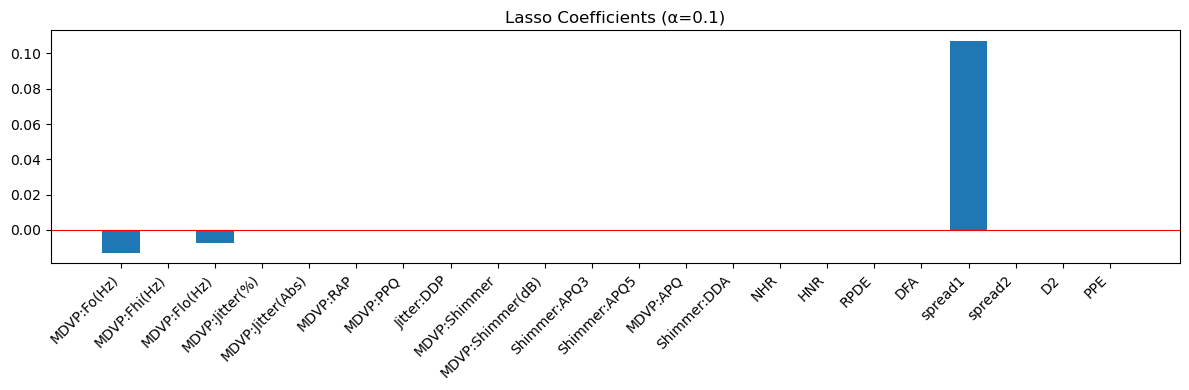

In [4]:
# Step 0: Load dataset B

feature_cols = [c for c in train_b.columns if c not in ("name", "subject_id", "status")]
X_train = train_b[feature_cols]
y_train = train_b["status"]

X_test = test_b[feature_cols]
y_test = test_b["status"]

# Step 1: data normalization

#X_train = np.log1p(X_train)
#X_test  = np.log1p(X_test)

scaler  = StandardScaler().fit(X_train) # fit() learns mean and std parameters
X_train = scaler.transform(X_train) # transform() normalizes
X_test  = scaler.transform(X_test)
    
# Step 2: Hyperparameter Tuning with Lasso (L1 regularization) and GridSearchCV (5-fold Cross validation)
param_grid = {'alpha': np.logspace(-6, 6, 13)}

lasso_grid = GridSearchCV(
    Lasso(fit_intercept=True, max_iter=10000),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)
lasso_grid.fit(X_train, y_train)

best_lasso   = lasso_grid.best_estimator_
w_star_Lasso = best_lasso.coef_
print(w_star_Lasso)
print(f"Best alpha: {lasso_grid.best_params_['alpha']}")

# Tuning with Ridge regression (L2 regularization) for comparison
ridge_grid = GridSearchCV(
    Ridge(fit_intercept=True, max_iter=10000),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)
ridge_grid.fit(X_train, y_train)

best_ridge   = ridge_grid.best_estimator_
w_star_Ridge = best_ridge.coef_
print(w_star_Ridge)
print(f"Best alpha: {ridge_grid.best_params_['alpha']}")

# Step 3: Evaluate Scores
def get_scores(model, X_tr, y_tr, X_te, y_te):
    for split_name, X, y in [("Train", X_tr, y_tr), ("Test", X_te, y_te)]:
        pred = model.predict(X)
        print(f"  {split_name}: R²={r2_score(y, pred):.3f}  "
              f"MSE={mean_squared_error(y, pred):.3f}  "
              f"MAE={mean_absolute_error(y, pred):.3f}  "
              f"RMSE={root_mean_squared_error(y, pred):.3f}")

print("\nLasso scores (Dataset B):")
get_scores(best_lasso, X_train, y_train, X_test, y_test)


print("\nRidge scores (Dataset B):")
get_scores(best_ridge, X_train, y_train, X_test, y_test)


# Step 4: Feature Selection via Lasso 
selected_idx   = np.where(w_star_Lasso != 0)[0]
selected_names = [feature_cols[i] for i in selected_idx]
print(f"\nSelected features ({len(selected_idx)}/{len(feature_cols)}): {selected_names}")

# Visualize
plt.figure(figsize=(12, 4))
plt.bar(feature_cols, w_star_Lasso)
plt.axhline(0, color='red', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.title(f"Lasso Coefficients (α={lasso_grid.best_params_['alpha']})")
plt.tight_layout()
plt.show()


Pipeline function fot Logistic Regression with Lasso regularization (L1) and Ridge(L2):

In [5]:

def run_pipeline(train_df, test_df, dataset_name):

    feature_cols = [
        c for c in train_df.columns
        if c not in ("name", "subject_id", "status")
    ]

    X_train = train_df[feature_cols]
    y_train = train_df["status"]
    X_test = test_df[feature_cols]
    y_test = test_df["status"]

    scaler = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    param_grid = {'C': np.logspace(-3, 3, 10)}

    lasso_grid = GridSearchCV(
        LogisticRegression(
            penalty='l1',
            solver='liblinear',
            class_weight='balanced',
            max_iter=10000,
            random_state=42
        ),
        param_grid,
        cv=5,
        scoring='f1'
    )

    lasso_grid.fit(X_train, y_train)
    best_lasso = lasso_grid.best_estimator_
    w_star = best_lasso.coef_[0]

    print(f"\n{'='*60}")
    print(dataset_name)
    print(f"{'='*60}")
    print("\nBest C:")
    print(lasso_grid.best_params_['C'])

    y_pred = best_lasso.predict(X_test)
    y_prob = best_lasso.predict_proba(X_test)[:, 1]

    accuracy  = accuracy_score(y_test, y_pred)
    bal_acc   = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    macro_f1  = f1_score(y_test, y_pred, average='macro')
    roc_auc   = roc_auc_score(y_test, y_prob)

    print("\nTest set performance:\n")
    print(f"Accuracy          : {accuracy:.3f}")
    print(f"Balanced Accuracy : {bal_acc:.3f}")
    print(f"Precision         : {precision:.3f}")
    print(f"Recall            : {recall:.3f}")
    print(f"F1-score (PD)     : {f1:.3f}")
    print(f"Macro F1          : {macro_f1:.3f}")
    print(f"ROC-AUC           : {roc_auc:.3f}")

    selected_idx = np.where(w_star != 0)[0]
    selected_features = [feature_cols[i] for i in selected_idx]
    print(f"\nSelected features ({len(selected_idx)}/{len(feature_cols)}):")
    print(selected_features)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = LogisticRegression(
            penalty='l1', solver='liblinear', class_weight='balanced',
            C=lasso_grid.best_params_['C'], max_iter=10000, random_state=42
        )
        model.fit(X_tr, y_tr)
        y_pred_cv = model.predict(X_val)
        y_prob_cv = model.predict_proba(X_val)[:, 1]

        metrics['accuracy'].append(accuracy_score(y_val, y_pred_cv))
        metrics['precision'].append(precision_score(y_val, y_pred_cv))
        metrics['recall'].append(recall_score(y_val, y_pred_cv))
        metrics['f1'].append(f1_score(y_val, y_pred_cv))
        metrics['roc_auc'].append(roc_auc_score(y_val, y_prob_cv))

    print("\nCross-validation stability:\n")
    for metric_name, values in metrics.items():
        print(f"{metric_name.capitalize()}: {np.mean(values):.3f} ± {np.std(values):.3f}")

    return {
        'Dataset': dataset_name,
        'Accuracy': accuracy,
        'Balanced_Acc': bal_acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Macro_F1': macro_f1,
        'ROC_AUC': roc_auc,
        'Selected_Features': selected_features,
    }

#Results for Dataset A (imputed):
results_a = run_pipeline(train_a, test_a, "Dataset A (imputation)")

#Results for Dataset B (dropped):
results_b = run_pipeline(train_b, test_b, "Dataset B (dropped)")

comparison_js = pd.DataFrame([results_a, results_b])
print(comparison_js)


Dataset A (imputation)

Best C:
0.46415888336127775

Test set performance:

Accuracy          : 0.930
Balanced Accuracy : 0.875
Precision         : 0.912
Recall            : 1.000
F1-score (PD)     : 0.954
Macro F1          : 0.905
ROC-AUC           : 0.981

Selected features (8/22):
['MDVP:Fo(Hz)', 'MDVP:Jitter(%)', 'MDVP:APQ', 'NHR', 'HNR', 'spread1', 'D2', 'PPE']

Cross-validation stability:

Accuracy: 0.763 ± 0.053
Precision: 0.909 ± 0.034
Recall: 0.767 ± 0.058
F1: 0.831 ± 0.039
Roc_auc: 0.888 ± 0.053

Dataset B (dropped)

Best C:
2.154434690031882

Test set performance:

Accuracy          : 0.878
Balanced Accuracy : 0.792
Precision         : 0.853
Recall            : 1.000
F1-score (PD)     : 0.921
Macro F1          : 0.829
ROC-AUC           : 0.911

Selected features (16/22):
['MDVP:Fo(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'Jitter:DDP', 'Shimmer:APQ3', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'D2', 'PPE']

Cross-validat

In [6]:

# Load Dataset A
feature_cols = [c for c in train_a.columns
    if c not in ("name", "subject_id", "status")]

X_train = train_a[feature_cols]
y_train = train_a["status"]
X_test = test_a[feature_cols]
y_test = test_a["status"]

# Step 1: Data Normalization
# Optional log transformation
# X_train = np.log1p(X_train)
# X_test  = np.log1p(X_test)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


# Step 2A: Lasso Logistic Regression (L1)
param_grid = {'C': np.logspace(-3, 3, 10)}
#GridSearchCV will automatically perform 5-fold cross-validation for each C value and select the best one based on F1-score
#for Hyperparameter tuning
lasso_grid = GridSearchCV(
    LogisticRegression(
        fit_intercept=True,
        max_iter=10000,
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='f1'
)

lasso_grid.fit(X_train, y_train)
best_lasso = lasso_grid.best_estimator_
w_star_Lasso = best_lasso.coef_[0]

print("\nBest Lasso C:")
print(lasso_grid.best_params_['C'])


# Ridge Logistic Regression (L2)
ridge_grid = GridSearchCV(
    LogisticRegression(
        fit_intercept=True,
        max_iter=10000,
        penalty='l2',
        solver='liblinear',
        class_weight='balanced',
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='f1'
)

ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_

w_star_Ridge = best_ridge.coef_[0]

print("\nBest Ridge C:")
print(ridge_grid.best_params_['C'])



# Step 3: Evaluation Function

def evaluate_model(model, X, y, model_name):

    y_pred = model.predict(X)

    y_prob = model.predict_proba(X)[:, 1]

    accuracy = accuracy_score(y, y_pred)

    precision = precision_score(y, y_pred)

    recall = recall_score(y, y_pred)

    f1 = f1_score(y, y_pred)

    roc_auc = roc_auc_score(y, y_prob)

    print(f"\n{model_name}")
    print(f"Accuracy : {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1-score : {f1:.3f}")
    print(f"ROC-AUC  : {roc_auc:.3f}")


# Step 4: Evaluate on Test Set
# Evaluate Lasso on Test Set
evaluate_model(
    best_lasso,
    X_test,
    y_test,
    "Lasso Logistic Regression"
)
#Evaluate Ridge on Test Set
evaluate_model(
    best_ridge,
    X_test,
    y_test,
    "Ridge Logistic Regression"
)


# Step 5: Feature Selection via Lasso
selected_idx = np.where(w_star_Lasso != 0)[0]
print(w_star_Lasso)
selected_names = [feature_cols[i] for i in selected_idx]
print(f"\nSelected features ({len(selected_idx)}/{len(feature_cols)}):")
print(selected_names)







Best Lasso C:
0.46415888336127775

Best Ridge C:
2.154434690031882

Lasso Logistic Regression
Accuracy : 0.930
Precision: 0.912
Recall   : 1.000
F1-score : 0.954
ROC-AUC  : 0.981

Ridge Logistic Regression
Accuracy : 0.884
Precision: 0.861
Recall   : 1.000
F1-score : 0.925
ROC-AUC  : 0.927
[-0.28891319  0.          0.         -0.05076488  0.          0.
  0.          0.          0.          0.          0.          0.
  0.56904627  0.         -0.17318607  0.07861103  0.          0.
  1.11354619  0.          0.36325411  0.80669165]

Selected features (8/22):
['MDVP:Fo(Hz)', 'MDVP:Jitter(%)', 'MDVP:APQ', 'NHR', 'HNR', 'spread1', 'D2', 'PPE']


Cross-Validation Results (Dataset A):
--> predict performance stability

In [7]:
# Cross-Validation Mean ± Std Metrics
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
metrics = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'roc_auc': []
}

# Use best Lasso model
for train_idx, val_idx in cv.split(X_train, y_train):
    # Split folds
    X_tr = X_train[train_idx]
    X_val = X_train[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    # Train model
    model = LogisticRegression(
        fit_intercept=True,
        max_iter=10000,
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        C=lasso_grid.best_params_['C'],
        random_state=42
    )
    model.fit(X_tr, y_tr)

    # Predictions
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    # Store metrics
    metrics['accuracy'].append(
        accuracy_score(y_val, y_pred)
    )
    metrics['precision'].append(
        precision_score(y_val, y_pred)
    )
    metrics['recall'].append(
        recall_score(y_val, y_pred)
    )
    metrics['f1'].append(
        f1_score(y_val, y_pred)
    )
    metrics['roc_auc'].append(
        roc_auc_score(y_val, y_prob)
    )

# Compute mean ± std
print("\nCross-validation performance (mean ± std):\n for Lasso Logistic Regression (Dataset A)\n")
for metric_name, values in metrics.items():
    mean_value = np.mean(values)
    std_value = np.std(values)
    print(
        f"{metric_name.capitalize()}: "
        f"{mean_value:.3f} ± {std_value:.3f}"
    )


Cross-validation performance (mean ± std):
 for Lasso Logistic Regression (Dataset A)

Accuracy: 0.763 ± 0.053
Precision: 0.909 ± 0.034
Recall: 0.767 ± 0.058
F1: 0.831 ± 0.039
Roc_auc: 0.888 ± 0.053


Results from Dataset B (deleted) with Logistic Regression with Lasso regularization (L1) and Ridge(L2):

In [8]:
# Load Dataset B
feature_cols = [c for c in train_b.columns
    if c not in ("name", "subject_id", "status")]

X_train_b = train_b[feature_cols]
y_train_b = train_b["status"]
X_test_b = test_b[feature_cols]
y_test_b = test_b["status"]

# Step 1: Data Normalization
# Optional log transformation
# X_train = np.log1p(X_train)
# X_test  = np.log1p(X_test)

scaler = StandardScaler().fit(X_train_b)
X_train_b = scaler.transform(X_train_b)
X_test_b = scaler.transform(X_test_b)


# Step 2A: Lasso Logistic Regression (L1)
param_grid = {'C': np.logspace(-3, 3, 10)}
#GridSearchCV will automatically perform 5-fold cross-validation for each C value and select the best one based on F1-score
#for Hyperparameter tuning
lasso_grid = GridSearchCV(
    LogisticRegression(
        fit_intercept=True,
        max_iter=10000,
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='f1'
)

lasso_grid.fit(X_train_b, y_train_b)
best_lasso = lasso_grid.best_estimator_
w_star_Lasso = best_lasso.coef_[0]

print("\nBest Lasso C:")
print(lasso_grid.best_params_['C'])


# Ridge Logistic Regression (L2)
ridge_grid = GridSearchCV(
    LogisticRegression(
        fit_intercept=True,
        max_iter=10000,
        penalty='l2',
        solver='liblinear',
        class_weight='balanced',
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='f1'
)

ridge_grid.fit(X_train_b, y_train_b)

best_ridge = ridge_grid.best_estimator_

w_star_Ridge = best_ridge.coef_[0]

print("\nBest Ridge C:")
print(ridge_grid.best_params_['C'])



# Step 3: Evaluation Function

def evaluate_model(model, X, y, model_name):

    y_pred = model.predict(X)

    y_prob = model.predict_proba(X)[:, 1]

    accuracy = accuracy_score(y, y_pred)

    precision = precision_score(y, y_pred)

    recall = recall_score(y, y_pred)

    f1 = f1_score(y, y_pred)

    roc_auc = roc_auc_score(y, y_prob)

    print(f"\n{model_name}")
    print(f"Accuracy : {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1-score : {f1:.3f}")
    print(f"ROC-AUC  : {roc_auc:.3f}")


# Step 4: Evaluate on Test Set
# Evaluate Lasso on Test Set
evaluate_model(
    best_lasso,
    X_test_b,
    y_test_b,
    "Lasso Logistic Regression"
)
#Evaluate Ridge on Test Set
evaluate_model(
    best_ridge,
    X_test_b,
    y_test_b,
    "Ridge Logistic Regression"
)


# Step 5: Feature Selection via Lasso
selected_idx = np.where(w_star_Lasso != 0)[0]
print(w_star_Lasso)
selected_names = [feature_cols[i] for i in selected_idx]
print(f"\nSelected features ({len(selected_idx)}/{len(feature_cols)}):")
print(selected_names)





Best Lasso C:
2.154434690031882

Best Ridge C:
10.0

Lasso Logistic Regression
Accuracy : 0.878
Precision: 0.853
Recall   : 1.000
F1-score : 0.921
ROC-AUC  : 0.911

Ridge Logistic Regression
Accuracy : 0.878
Precision: 0.853
Recall   : 1.000
F1-score : 0.921
ROC-AUC  : 0.891
[-0.35154874  0.          0.21843394 -0.48430721 -0.40575858  0.42531733
  0.          0.54914595  0.          0.         -1.27091842  0.
  6.72951641 -1.73002369 -0.47420533  1.21937121  0.25671384 -0.54366058
  0.71631549  0.          0.69524494  2.23870766]

Selected features (16/22):
['MDVP:Fo(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'Jitter:DDP', 'Shimmer:APQ3', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'D2', 'PPE']


Consistent markers in both Dataset A and B: 
MDVP:Fo(Hz)
MDVP:Jitter(%)
MDVP:APQ
NHR
HNR
spread1
D2
PPE
--> consistently predictive in both situation


Cross-Validation Results (Dataset B):
--> predict performance stability

In [9]:
# Cross-Validation Mean ± Std Metrics
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
metrics = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'roc_auc': []
}

# Use best Lasso model
for train_idx, val_idx in cv.split(X_train_b, y_train_b):
    # Split folds
    X_tr = X_train_b[train_idx]
    X_val = X_train_b[val_idx]

    y_tr = y_train_b.iloc[train_idx]
    y_val = y_train_b.iloc[val_idx]

    # Train model
    model = LogisticRegression(
        fit_intercept=True,
        max_iter=10000,
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        C=lasso_grid.best_params_['C'],
        random_state=42
    )
    model.fit(X_tr, y_tr)

    # Predictions
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    # Store metrics
    metrics['accuracy'].append(
        accuracy_score(y_val, y_pred)
    )
    metrics['precision'].append(
        precision_score(y_val, y_pred)
    )
    metrics['recall'].append(
        recall_score(y_val, y_pred)
    )
    metrics['f1'].append(
        f1_score(y_val, y_pred)
    )
    metrics['roc_auc'].append(
        roc_auc_score(y_val, y_prob)
    )

# Compute mean ± std
print("\nCross-validation performance (mean ± std):\n for Lasso Logistic Regression (Dataset B)\n")
for metric_name, values in metrics.items():
    mean_value = np.mean(values)
    std_value = np.std(values)
    print(
        f"{metric_name.capitalize()}: "
        f"{mean_value:.3f} ± {std_value:.3f}"
    )


Cross-validation performance (mean ± std):
 for Lasso Logistic Regression (Dataset B)

Accuracy: 0.774 ± 0.107
Precision: 0.909 ± 0.077
Recall: 0.786 ± 0.111
F1: 0.840 ± 0.086
Roc_auc: 0.882 ± 0.104


The F1 performance from dataset B (Deletion) ist slightly better than dataset A (Imputation), but the stability of Dataset B is worse, because its std is bigger.


!!! Train with only Jitter and Schimmer relevant features:

In [10]:
def run_js_pipeline(train_df, test_df, dataset_name):

    feature_cols = [
        c for c in train_df.columns
        if c not in ("name", "subject_id", "status")
    ]

    js_features = [
        c for c in feature_cols
        if ("Jitter" in c) or ("Shimmer" in c)
    ]

    print(f"\n{'='*60}")
    print(dataset_name)
    print(f"{'='*60}")
    print("\nJitter/Shimmer features:")
    print(js_features)

    X_train = train_df[js_features]
    y_train = train_df["status"]
    X_test = test_df[js_features]
    y_test = test_df["status"]

    scaler = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    param_grid = {'C': np.logspace(-3, 3, 10)}

    lasso_grid = GridSearchCV(
        LogisticRegression(
            penalty='l1',
            solver='liblinear',
            class_weight='balanced',
            max_iter=10000,
            random_state=42
        ),
        param_grid,
        cv=5,
        scoring='f1'
    )

    lasso_grid.fit(X_train, y_train)
    best_model = lasso_grid.best_estimator_
    coefficients = best_model.coef_[0]

    print("\nBest Lasso C:")
    print(lasso_grid.best_params_['C'])
    print("\nLasso coefficients:")
    print(coefficients)

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    accuracy  = accuracy_score(y_test, y_pred)
    bal_acc   = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    macro_f1  = f1_score(y_test, y_pred, average='macro')
    roc_auc   = roc_auc_score(y_test, y_prob)

    print("\nTest set performance:\n")
    print(f"Accuracy          : {accuracy:.3f}")
    print(f"Balanced Accuracy : {bal_acc:.3f}")
    print(f"Precision         : {precision:.3f}")
    print(f"Recall            : {recall:.3f}")
    print(f"F1-score (PD)     : {f1:.3f}")
    print(f"Macro F1          : {macro_f1:.3f}")
    print(f"ROC-AUC           : {roc_auc:.3f}")

    selected_idx = np.where(coefficients != 0)[0]
    selected_features = [js_features[i] for i in selected_idx]
    print(f"\nSelected features ({len(selected_idx)}/{len(js_features)}):")
    print(selected_features)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = LogisticRegression(
            penalty='l1', solver='liblinear', class_weight='balanced',
            C=lasso_grid.best_params_['C'], max_iter=10000, random_state=42
        )
        model.fit(X_tr, y_tr)
        y_pred_cv = model.predict(X_val)
        y_prob_cv = model.predict_proba(X_val)[:, 1]

        metrics['accuracy'].append(accuracy_score(y_val, y_pred_cv))
        metrics['precision'].append(precision_score(y_val, y_pred_cv))
        metrics['recall'].append(recall_score(y_val, y_pred_cv))
        metrics['f1'].append(f1_score(y_val, y_pred_cv))
        metrics['roc_auc'].append(roc_auc_score(y_val, y_prob_cv))

    print("\nCross-validation stability:\n")
    for metric_name, values in metrics.items():
        print(f"{metric_name.capitalize()}: {np.mean(values):.3f} ± {np.std(values):.3f}")

    return {
        'Dataset': dataset_name,
        'Accuracy': accuracy,
        'Balanced_Acc': bal_acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Macro_F1': macro_f1,
        'ROC_AUC': roc_auc,
        'Selected_Features': selected_features,
    }

In [11]:
results_js_a = run_js_pipeline(
    train_a,
    test_a,
    "Dataset A - JS only"
)

results_js_b = run_js_pipeline(
    train_b,
    test_b,
    "Dataset B - JS only"
)

comparison_js = pd.DataFrame([
    results_js_a,
    results_js_b
])

print(comparison_js)



Dataset A - JS only

Jitter/Shimmer features:
['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:DDA']

Best Lasso C:
10.0

Lasso coefficients:
[-6.05592665  4.31051098  3.40582532  4.42051657  0.10763272 -2.2959706
  2.14207256 -2.66909973]

Test set performance:

Accuracy          : 0.884
Balanced Accuracy : 0.792
Precision         : 0.861
Recall            : 1.000
F1-score (PD)     : 0.925
Macro F1          : 0.831
ROC-AUC           : 0.952

Selected features (8/8):
['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:DDA']

Cross-validation stability:

Accuracy: 0.698 ± 0.047
Precision: 0.894 ± 0.055
Recall: 0.690 ± 0.074
F1: 0.775 ± 0.042
Roc_auc: 0.815 ± 0.083

Dataset B - JS only

Jitter/Shimmer features:
['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 

In [12]:

#1. Jitter + Shimmer feature subset
js_features = [
    c for c in feature_cols
    if ("Jitter" in c) or ("Shimmer" in c)
]

print("\nJitter/Shimmer features:")
print(js_features)

#dataset A (imputed) and dataset B (dropped) have the same Jitter/Shimmer features, so we can use js_features for both datasets
#dataset A (imputed)
X_train_js_a = train_a[js_features]
y_train_a = train_a["status"]

X_test_js_a = test_a[js_features]
y_test_a = test_a["status"]


#dataset B (dropped)
X_train_js_b = train_b[js_features]
y_train_b = train_b["status"]

X_test_js_b = test_b[js_features]
y_test_b = test_b["status"]


#2. Normalize Jitter/Shimmer features
# Dataset A (imputed)
scaler_js_a = StandardScaler().fit(X_train_js_a)
X_train_js_a = scaler_js_a.transform(X_train_js_a)
X_test_js_a = scaler_js_a.transform(X_test_js_a)

# Dataset B (dropped)
scaler_js_b = StandardScaler().fit(X_train_js_b)
X_train_js_b = scaler_js_b.transform(X_train_js_b)
X_test_js_b = scaler_js_b.transform(X_test_js_b)


# Step 3: Lasso Logistic Regression (L1) on Jitter/Shimmer features
param_grid = {'C': np.logspace(-3, 3, 10)}
# Dataset A (imputed)
lasso_grid_a = GridSearchCV(
    LogisticRegression(
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        max_iter=10000,
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='f1'
)

lasso_grid_a.fit(X_train_js_a, y_train_a)
best_lasso_a = lasso_grid_a.best_estimator_
w_star_Lasso = best_lasso_a.coef_[0]

print("\nBest Lasso C (Dataset A):")
print(lasso_grid_a.best_params_['C'])
print("\nLasso coefficients (Dataset A):")
print(w_star_Lasso)

# Dataset B (dropped)
lasso_grid_b = GridSearchCV(
    LogisticRegression(
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        max_iter=10000,
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='f1'
)
lasso_grid_b.fit(X_train_js_b, y_train_b)
best_lasso_b = lasso_grid_b.best_estimator_
w_star_Lasso_b = best_lasso_b.coef_[0]

print("\nBest Lasso C (Dataset B):")
print(lasso_grid_b.best_params_['C'])
print("\nLasso coefficients (Dataset B):")
print(w_star_Lasso_b)


#Step 4: Evaluation
evaluate_model(
    best_lasso_a,
    X_test_js_a,
    y_test_a,
    "Dataset A - Jitter/Shimmer Only"
)

evaluate_model(
    best_lasso_b,
    X_test_js_b,
    y_test_b,
    "Dataset B - Jitter/Shimmer Only"
)

# Step 5: Feature Selection via Lasso
# Feature selection via L1 (Dataset A)
selected_idx_a = np.where(w_star_Lasso != 0)[0]
selected_features_a = [
    js_features[i]
    for i in selected_idx_a
]
print(f"\nSelected features (Dataset A) ({len(selected_idx_a)}/{len(js_features)}):")
print(selected_features_a)

# Feature selection via L1 (Dataset B)
selected_idx_b = np.where(w_star_Lasso_b != 0)[0]

selected_features_b = [
    js_features[i]
    for i in selected_idx_b
]

print(f"\nSelected features (Dataset B) ({len(selected_idx_b)}/{len(js_features)}):")
print(selected_features_b)





Jitter/Shimmer features:
['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:DDA']

Best Lasso C (Dataset A):
10.0

Lasso coefficients (Dataset A):
[-6.05592665  4.31051098  3.40582532  4.42051657  0.10763272 -2.2959706
  2.14207256 -2.66909973]

Best Lasso C (Dataset B):
46.41588833612773

Lasso coefficients (Dataset B):
[-10.12403066   3.12513934   8.91563612  52.92762586 -10.67649398
 -14.84232391  -7.38905752 -16.67770801]

Dataset A - Jitter/Shimmer Only
Accuracy : 0.884
Precision: 0.861
Recall   : 1.000
F1-score : 0.925
ROC-AUC  : 0.952

Dataset B - Jitter/Shimmer Only
Accuracy : 0.829
Precision: 0.844
Recall   : 0.931
F1-score : 0.885
ROC-AUC  : 0.868

Selected features (Dataset A) (8/8):
['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:DDA']

Selected features (Dataset B) (8/8):
['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'Ji

Cross-Validation Stability for only Jitter and Shimmer features:
--> predict performance stability

In [13]:

# Step 6A: Cross-validation stability
# Dataset A (Jitter/Shimmer only)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metrics_a = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'roc_auc': []
}

for train_idx, val_idx in cv.split(X_train_js_a, y_train_a):

    # Split folds
    X_tr = X_train_js_a[train_idx]
    X_val = X_train_js_a[val_idx]

    y_tr = y_train_a.iloc[train_idx]
    y_val = y_train_a.iloc[val_idx]

    # Train model
    model = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        C=lasso_grid_a.best_params_['C'],
        max_iter=10000,
        random_state=42
    )

    model.fit(X_tr, y_tr)

    # Predictions
    y_pred = model.predict(X_val)

    y_prob = model.predict_proba(X_val)[:,1]

    # Store metrics
    metrics_a['accuracy'].append(
        accuracy_score(y_val, y_pred)
    )

    metrics_a['precision'].append(
        precision_score(y_val, y_pred)
    )

    metrics_a['recall'].append(
        recall_score(y_val, y_pred)
    )

    metrics_a['f1'].append(
        f1_score(y_val, y_pred)
    )

    metrics_a['roc_auc'].append(
        roc_auc_score(y_val, y_prob)
    )


# Print results
print("\nCross-validation stability (Dataset A - Jitter/Shimmer only):\n")

for metric_name, values in metrics_a.items():

    print(
        f"{metric_name.capitalize()}: "
        f"{np.mean(values):.3f} ± {np.std(values):.3f}"
    )


# Dataset B (Deletion) (Jitter/Shimmer only)
# ─────────────────────────────────────────────────────────────
# Step 6B: Cross-validation stability
# Dataset B (Jitter/Shimmer only)
# ─────────────────────────────────────────────────────────────

metrics_b = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'roc_auc': []
}

for train_idx, val_idx in cv.split(X_train_js_b, y_train_b):

    X_tr = X_train_js_b[train_idx]
    X_val = X_train_js_b[val_idx]

    y_tr = y_train_b.iloc[train_idx]
    y_val = y_train_b.iloc[val_idx]

    model = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        C=lasso_grid_b.best_params_['C'],
        max_iter=10000,
        random_state=42
    )

    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)

    y_prob = model.predict_proba(X_val)[:,1]

    metrics_b['accuracy'].append(
        accuracy_score(y_val, y_pred)
    )

    metrics_b['precision'].append(
        precision_score(y_val, y_pred)
    )

    metrics_b['recall'].append(
        recall_score(y_val, y_pred)
    )

    metrics_b['f1'].append(
        f1_score(y_val, y_pred)
    )

    metrics_b['roc_auc'].append(
        roc_auc_score(y_val, y_prob)
    )


print("\nCross-validation stability (Dataset B - JS only):\n")

for metric_name, values in metrics_b.items():

    print(
        f"{metric_name.capitalize()}: "
        f"{np.mean(values):.3f} ± {np.std(values):.3f}"
    )



Cross-validation stability (Dataset A - Jitter/Shimmer only):

Accuracy: 0.698 ± 0.047
Precision: 0.894 ± 0.055
Recall: 0.690 ± 0.074
F1: 0.775 ± 0.042
Roc_auc: 0.815 ± 0.083

Cross-validation stability (Dataset B - JS only):

Accuracy: 0.767 ± 0.067
Precision: 0.931 ± 0.063
Recall: 0.760 ± 0.079
F1: 0.833 ± 0.052
Roc_auc: 0.890 ± 0.067


In the linear regression model, the performance of JS-only model is only slightly lower than full-feature model, which means jitter/shimmer features alone already capture most predictive information for Parkinson disease. 
--> Vocal instability measures (jitter/shimmer) possess strong predictive power for Parkinson classification



train Without Outliers

In [14]:
from sklearn.decomposition import PCA

_feat_cols = [c for c in train_a.columns if c not in ("name", "subject_id", "status")]

def _fit_outlier_detector(train_df, feat_cols):
    """Fit IQR bounds, scaler, PCA(2), and Mahalanobis threshold on train_df."""
    _iqr_bounds = {}
    for c in feat_cols:
        Q1, Q3 = train_df[c].quantile(0.25), train_df[c].quantile(0.75)
        _iqr_bounds[c] = (Q1 - 1.5 * (Q3 - Q1), Q3 + 1.5 * (Q3 - Q1))

    _scaler   = StandardScaler().fit(train_df[feat_cols])
    _X_sc_tr  = _scaler.transform(train_df[feat_cols])
    _pca      = PCA(n_components=2).fit(_X_sc_tr)
    _X_pca_tr = _pca.transform(_X_sc_tr)

    _mu      = _X_pca_tr.mean(axis=0)
    _cov_inv = np.linalg.pinv(np.cov(_X_pca_tr.T))
    _d       = _X_pca_tr - _mu
    _thresh  = np.percentile(np.sqrt(np.einsum("ij,jk,ik->i", _d, _cov_inv, _d)), 97.5)
    return _iqr_bounds, _scaler, _pca, _mu, _cov_inv, _thresh


def _apply_outlier_flags(df, feat_cols, _iqr_bounds, _scaler, _pca, _mu, _cov_inv, _thresh):
    """Apply fitted detector to df; returns set of outlier recording names."""
    _iqr_count = np.zeros(len(df), dtype=int)
    for c, (lo, hi) in _iqr_bounds.items():
        _iqr_count += ((df[c].values < lo) | (df[c].values > hi)).astype(int)

    _X_sc  = _scaler.transform(df[feat_cols])
    _X_pca = _pca.transform(_X_sc)
    _d     = _X_pca - _mu
    _mahal = np.sqrt(np.einsum("ij,jk,ik->i", _d, _cov_inv, _d))
    _mask  = (_iqr_count >= 3) | (np.abs(_X_sc) > 3).any(axis=1) | (_mahal > _thresh)
    return set(df["name"].values[_mask])


# Dataset A: fit on train_a, apply to train_a and test_a
_det_a = _fit_outlier_detector(train_a, _feat_cols)
_train_a_outlier_names = _apply_outlier_flags(train_a, _feat_cols, *_det_a)
_test_a_outlier_names  = _apply_outlier_flags(test_a,  _feat_cols, *_det_a)

# Dataset B: fit on train_b, apply to train_b and test_b
_det_b = _fit_outlier_detector(train_b, _feat_cols)
_train_b_outlier_names = _apply_outlier_flags(train_b, _feat_cols, *_det_b)
_test_b_outlier_names  = _apply_outlier_flags(test_b,  _feat_cols, *_det_b)

print(f"Outliers A — train: {len(_train_a_outlier_names)}, test: {len(_test_a_outlier_names)}")
print(f"Outliers B — train: {len(_train_b_outlier_names)}, test: {len(_test_b_outlier_names)}")

# Filter train/test splits
train_a_clean = train_a[~train_a["name"].isin(_train_a_outlier_names)].reset_index(drop=True)
test_a_clean  = test_a[~test_a["name"].isin(_test_a_outlier_names)].reset_index(drop=True)
train_b_clean = train_b[~train_b["name"].isin(_train_b_outlier_names)].reset_index(drop=True)
test_b_clean  = test_b[~test_b["name"].isin(_test_b_outlier_names)].reset_index(drop=True)

print(f"Train A: {len(train_a)} → {len(train_a_clean)} | Test A: {len(test_a)} → {len(test_a_clean)}")
print(f"Train B: {len(train_b)} → {len(train_b_clean)} | Test B: {len(test_b)} → {len(test_b_clean)}")


Outliers A — train: 22, test: 7
Outliers B — train: 21, test: 7
Train A: 152 → 130 | Test A: 43 → 36
Train B: 146 → 125 | Test B: 41 → 34


In [15]:
# All features, without outliers
results_a_clean = run_pipeline(
    train_a_clean, test_a_clean,
    "Dataset A (without outliers)",
)

results_b_clean = run_pipeline(
    train_b_clean, test_b_clean,
    "Dataset B (without outliers)",
)

pd.DataFrame([results_a_clean, results_b_clean])


Dataset A (without outliers)

Best C:
2.154434690031882

Test set performance:

Accuracy          : 0.889
Balanced Accuracy : 0.800
Precision         : 0.867
Recall            : 1.000
F1-score (PD)     : 0.929
Macro F1          : 0.839
ROC-AUC           : 0.865

Selected features (19/22):
['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:RAP', 'MDVP:PPQ', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

Cross-validation stability:

Accuracy: 0.777 ± 0.057
Precision: 0.906 ± 0.075
Recall: 0.777 ± 0.039
F1: 0.834 ± 0.040
Roc_auc: 0.883 ± 0.067

Dataset B (without outliers)

Best C:
0.46415888336127775

Test set performance:

Accuracy          : 0.912
Balanced Accuracy : 0.850
Precision         : 0.889
Recall            : 1.000
F1-score (PD)     : 0.941
Macro F1          : 0.882
ROC-AUC           : 0.954

Selected features (10/22):
['MDVP:Fo(Hz)', 'MDVP:Jitter(%)', 'Shimme

,Dataset,Accuracy,Balanced_Acc,Precision,Recall,F1,Macro_F1,ROC_AUC,Selected_Features
0,Dataset A (without outliers),0.888889,0.80,0.866667,1.0,0.928571,0.839286,0.865385,"[MDVP:Fo(Hz), MDVP:Fhi(Hz), MDVP:Flo(Hz), MDVP..."
1,Dataset B (without outliers),0.911765,0.85,0.888889,1.0,0.941176,0.882353,0.954167,"[MDVP:Fo(Hz), MDVP:Jitter(%), Shimmer:APQ3, MD..."


In [16]:
# ── Jitter+Shimmer, without outliers ─────────────────────────────────────────
results_js_a_clean = run_js_pipeline(
    train_a_clean, test_a_clean,
    "Dataset A - JS only (without outliers)",
)

results_js_b_clean = run_js_pipeline(
    train_b_clean, test_b_clean,
    "Dataset B - JS only (without outliers)",
)

pd.DataFrame([results_js_a_clean, results_js_b_clean])


Dataset A - JS only (without outliers)

Jitter/Shimmer features:
['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:DDA']

Best Lasso C:
46.41588833612773

Lasso coefficients:
[-3.09101287e+00  2.55754463e+00  1.78799652e+00  2.90123912e+00
  9.05514699e-04 -1.47557995e+00  1.01733796e+00 -1.82939548e+00]

Test set performance:

Accuracy          : 0.889
Balanced Accuracy : 0.800
Precision         : 0.867
Recall            : 1.000
F1-score (PD)     : 0.929
Macro F1          : 0.839
ROC-AUC           : 0.923

Selected features (8/8):
['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:DDA']

Cross-validation stability:

Accuracy: 0.685 ± 0.075
Precision: 0.855 ± 0.084
Recall: 0.692 ± 0.094
F1: 0.758 ± 0.062
Roc_auc: 0.745 ± 0.133

Dataset B - JS only (without outliers)

Jitter/Shimmer features:
['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)'

,Dataset,Accuracy,Balanced_Acc,Precision,Recall,F1,Macro_F1,ROC_AUC,Selected_Features
0,Dataset A - JS only (without outliers),0.888889,0.8000,0.866667,1.000,0.928571,0.839286,0.923077,"[MDVP:Jitter(%), MDVP:Jitter(Abs), Jitter:DDP,..."
1,Dataset B - JS only (without outliers),0.794118,0.7375,0.840000,0.875,0.857143,0.744361,0.837500,"[MDVP:Jitter(%), MDVP:Jitter(Abs), Jitter:DDP,..."
